<a href="https://colab.research.google.com/github/silviaparente/computational_astrobiology/blob/main/naive_bayes_habitable_zone_exoplanet_archive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes classification of habitable-zone membership from NASA Exoplanet Archive data

This notebook is designed for **Google Colab** and shows how to build a **Gaussian Naive Bayes** classifier to predict whether a confirmed exoplanet falls into a **simple habitable-zone label**.

## Important scientific note

This notebook uses a **toy habitable-zone classification** for teaching machine learning. It is **not** a full physical habitability assessment.

The default label is defined from two archive quantities:

- stellar insolation `pl_insol`
- planetary radius `pl_rade`

We label a planet as:

- `1` = habitable-zone-like candidate if `0.25 <= pl_insol <= 1.75` and `pl_rade <= 1.8`
- `0` = otherwise

This is only a classroom proxy. Real habitability depends on many additional factors: atmosphere, stellar variability, chemistry, tidal effects, age, magnetic environment, observational uncertainty, and model assumptions.

## What students will learn

In this notebook, students will:

1. download confirmed exoplanet data from the NASA Exoplanet Archive,
2. define a toy habitable-zone target,
3. avoid label leakage by excluding the variables used to define the label,
4. train a **Gaussian Naive Bayes** classifier,
5. evaluate it with **Stratified K-Fold cross-validation**, and
6. inspect model behavior and limitations.


## 1. Install and import packages

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib requests

In [2]:
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)


## 2. Download data from the NASA Exoplanet Archive

We use the `pscomppars` table and request a compact set of columns that are useful for this exercise.

In [3]:
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = r"""
select
    pl_name,
    hostname,
    discoverymethod,
    pl_orbper,
    pl_orbsmax,
    pl_rade,
    pl_bmasse,
    pl_dens,
    pl_orbeccen,
    pl_eqt,
    pl_insol,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_snum,
    sy_pnum
from pscomppars
"""

url = f"{base_url}?query={urllib.parse.quote(query)}&format=csv"
df = pd.read_csv(url)

print('Raw dataset shape:', df.shape)
df.head()

Raw dataset shape: (6298, 19)


,pl_name,hostname,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,Kepler-1167 b,Kepler-1167,Transit,1.003934,0.01750,1.710000,3.570,3.92,0.0,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,1,1
1,Kepler-1740 b,Kepler-1740,Transit,8.172400,0.07790,3.323214,11.000,1.65,0.0,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,1,1
2,Kepler-1581 b,Kepler-1581,Transit,6.283855,0.06865,0.800000,0.437,4.69,0.0,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,1,1
3,Kepler-644 b,Kepler-644,Transit,3.173917,0.04641,3.150000,10.100,1.78,0.0,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,1,1
4,Kepler-1752 b,Kepler-1752,Transit,56.358501,0.26980,4.540605,18.700,1.10,0.0,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,1,1


## 3. Basic inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6298 non-null   object 
 1   hostname         6298 non-null   object 
 2   discoverymethod  6298 non-null   object 
 3   pl_orbper        5958 non-null   float64
 4   pl_orbsmax       5873 non-null   float64
 5   pl_rade          6248 non-null   float64
 6   pl_bmasse        6267 non-null   float64
 7   pl_dens          6157 non-null   float64
 8   pl_orbeccen      5247 non-null   float64
 9   pl_eqt           4693 non-null   float64
 10  pl_insol         4413 non-null   float64
 11  st_teff          6004 non-null   float64
 12  st_rad           5980 non-null   float64
 13  st_mass          6289 non-null   float64
 14  st_met           5659 non-null   float64
 15  st_logg          5976 non-null   float64
 16  sy_dist          6271 non-null   float64
 17  sy_snum       

In [5]:
df.isna().mean().sort_values(ascending=False)

,0
pl_insol,0.299301
pl_eqt,0.254843
pl_orbeccen,0.166878
st_met,0.101461
pl_orbsmax,0.067482
pl_orbper,0.053985
st_logg,0.051127
st_rad,0.050492
st_teff,0.046681
pl_dens,0.022388


## 4. Define the habitable-zone-like target

We first require the quantities needed to define the label.

### Toy label definition

A planet is labeled `hz_toy = 1` if:

- `pl_insol` is between 0.25 and 1.75 Earth insolation units,
- `pl_rade <= 1.8` Earth radii.

Otherwise, `hz_toy = 0`.

This gives a compact binary classification target suitable for class exercises.

In [6]:
df_hz = df.dropna(subset=['pl_insol', 'pl_rade']).copy()
df_hz['hz_toy'] = ((df_hz['pl_insol'].between(0.25, 1.75)) & (df_hz['pl_rade'] <= 1.8)).astype(int)

print('Dataset after requiring label-defining columns:', df_hz.shape)
print(df_hz['hz_toy'].value_counts())
print(df_hz['hz_toy'].value_counts(normalize=True))

Dataset after requiring label-defining columns: (4407, 20)
hz_toy
0    4364
1      43
Name: count, dtype: int64
hz_toy
0    0.990243
1    0.009757
Name: proportion, dtype: float64


## 5. Quick visualization of the toy habitable-zone rule

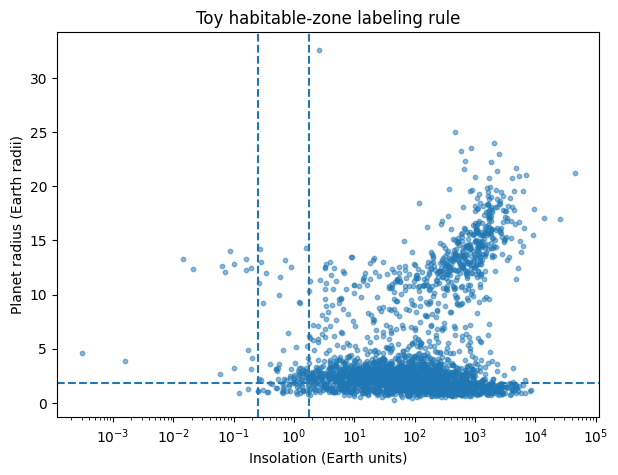

In [7]:
plt.figure(figsize=(7, 5))
subset = df_hz.sample(min(len(df_hz), 3000), random_state=42)
plt.scatter(subset['pl_insol'], subset['pl_rade'], s=10, alpha=0.5)
plt.axvline(0.25, linestyle='--')
plt.axvline(1.75, linestyle='--')
plt.axhline(1.8, linestyle='--')
plt.xscale('log')
plt.xlabel('Insolation (Earth units)')
plt.ylabel('Planet radius (Earth radii)')
plt.title('Toy habitable-zone labeling rule')
plt.show()

## 6. Choose predictor features carefully

To avoid **label leakage**, we do **not** use `pl_insol` or `pl_rade` as predictors, because they were used to define the target itself.

Instead, we predict the label using orbital and stellar/system properties.

In [8]:
feature_cols = [
    'pl_orbper',
    'pl_orbsmax',
    'pl_bmasse',
    'pl_dens',
    'pl_orbeccen',
    'pl_eqt',
    'st_teff',
    'st_rad',
    'st_mass',
    'st_met',
    'st_logg',
    'sy_dist',
    'sy_snum',
    'sy_pnum',
]

X = df_hz[feature_cols].copy()
y = df_hz['hz_toy'].copy()

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (4407, 14)
Target shape: (4407,)


## 7. Optional: log-transform skewed features

Some astrophysical quantities are very skewed. A log transform can make Gaussian Naive Bayes behave more sensibly.

We create a transformed copy for selected positive-valued features.

In [9]:
X_model = X.copy()

log_cols = ['pl_orbper', 'pl_orbsmax', 'pl_bmasse', 'pl_dens', 'pl_eqt', 'sy_dist']

for col in log_cols:
    X_model[col] = np.where(X_model[col] > 0, np.log10(X_model[col]), np.nan)

X_model.head()

,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,0.001705,-1.756962,0.552668,0.593286,0.0,3.151982,4971.0,0.750,0.790,-0.05,4.600,2.914293,1,1
1,0.912350,-1.108463,1.041393,0.217484,0.0,2.933487,5705.0,0.905,0.943,-0.06,4.499,3.026030,1,1
2,0.798226,-1.163359,-0.359519,0.671173,0.0,3.044540,6022.0,1.230,1.120,0.07,4.310,2.693001,1,1
3,0.501596,-1.333388,1.004321,0.250420,0.0,3.218798,6747.0,1.810,1.490,0.08,4.090,3.119932,1,1
4,1.750959,-0.568958,1.271842,0.041393,0.0,2.622214,5446.0,0.821,0.824,-0.20,4.525,2.983576,1,1


## 8. Build the Gaussian Naive Bayes pipeline

In [10]:
nb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', GaussianNB()),
])

nb_model

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf', GaussianNB())])

## 9. Stratified K-fold cross-validation

We use `StratifiedKFold` so that each fold preserves the class balance as much as possible.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## 10. Cross-validated metrics

We compute accuracy, precision, recall, F1, and ROC AUC.

Because the habitable-zone-like class may be imbalanced, you should pay attention especially to recall, precision, and ROC AUC.

In [12]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

cv_results = cross_validate(
    estimator=nb_model,
    X=X_model,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    metric: cv_results[f'test_{metric}']
    for metric in scoring.keys()
})

cv_summary

,accuracy,precision,recall,f1,roc_auc
0,0.936508,0.126984,0.888889,0.222222,0.977090
1,0.959184,0.186047,0.888889,0.307692,0.985236
2,0.953462,0.163265,1.000000,0.280702,0.990263
3,0.953462,0.116279,0.625000,0.196078,0.971077
4,0.945516,0.117647,0.666667,0.200000,0.926351


In [13]:
print('Cross-validation summary statistics:')
display(cv_summary.describe().T[['mean', 'std', 'min', 'max']])

Cross-validation summary statistics:


,mean,std,min,max
accuracy,0.949626,0.008800,0.936508,0.959184
precision,0.142044,0.031114,0.116279,0.186047
recall,0.813889,0.160655,0.625000,1.000000
f1,0.241339,0.050187,0.196078,0.307692
roc_auc,0.970003,0.025492,0.926351,0.990263


## 11. Plot fold-to-fold variation

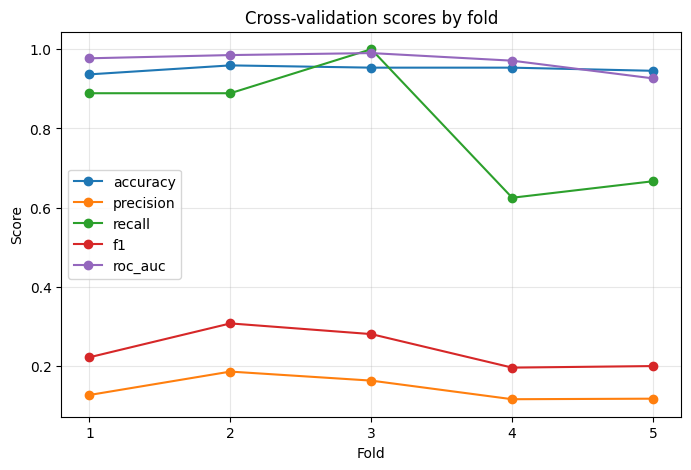

In [14]:
plt.figure(figsize=(8, 5))
for col in cv_summary.columns:
    plt.plot(range(1, len(cv_summary) + 1), cv_summary[col], marker='o', label=col)

plt.xticks(range(1, len(cv_summary) + 1))
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Cross-validation scores by fold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Out-of-fold predictions for the full dataset

These are cross-validated predictions, so each object is predicted by a model that was not trained on it.

In [15]:
y_pred_cv = cross_val_predict(nb_model, X_model, y, cv=cv, method='predict', n_jobs=-1)
y_proba_cv = cross_val_predict(nb_model, X_model, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

print(classification_report(y, y_pred_cv, digits=4))
print('Cross-validated ROC AUC:', roc_auc_score(y, y_proba_cv))

              precision    recall  f1-score   support

           0     0.9981    0.9510    0.9739      4364
           1     0.1406    0.8140    0.2397        43

    accuracy                         0.9496      4407
   macro avg     0.5693    0.8825    0.6068      4407
weighted avg     0.9897    0.9496    0.9668      4407

Cross-validated ROC AUC: 0.9658516829023938


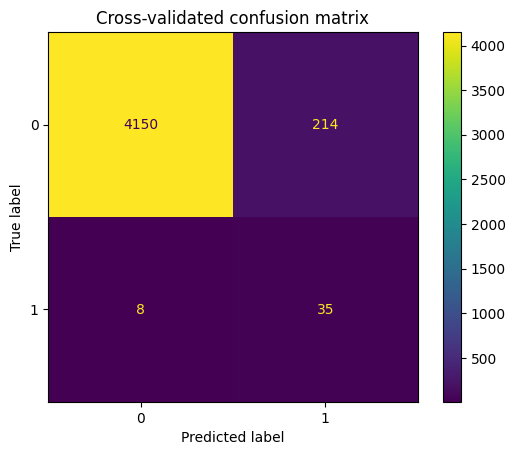

In [16]:
cm = confusion_matrix(y, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Cross-validated confusion matrix')
plt.show()

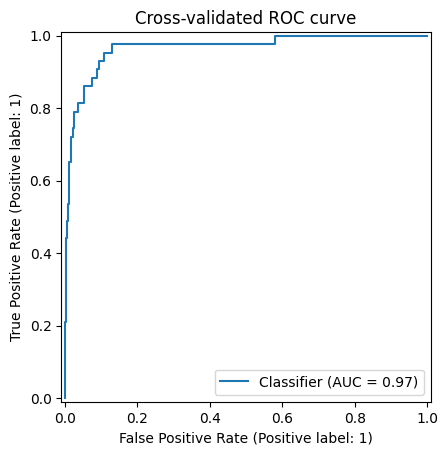

In [17]:
RocCurveDisplay.from_predictions(y, y_proba_cv)
plt.title('Cross-validated ROC curve')
plt.show()

## 13. Compare with a single train/test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

nb_model.fit(X_train, y_train)
y_pred_test = nb_model.predict(X_test)
y_proba_test = nb_model.predict_proba(X_test)[:, 1]

single_split_results = {
    'accuracy': accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test),
    'recall': recall_score(y_test, y_pred_test),
    'f1': f1_score(y_test, y_pred_test),
    'roc_auc': roc_auc_score(y_test, y_proba_test),
}

pd.Series(single_split_results, name='single_split')

,single_split
accuracy,0.950998
precision,0.135593
recall,0.727273
f1,0.228571
roc_auc,0.938505


In [19]:
comparison = pd.DataFrame({
    'cv_mean': cv_summary.mean(),
    'cv_std': cv_summary.std(),
    'single_split': pd.Series(single_split_results),
})

comparison

,cv_mean,cv_std,single_split
accuracy,0.949626,0.008800,0.950998
precision,0.142044,0.031114,0.135593
recall,0.813889,0.160655,0.727273
f1,0.241339,0.050187,0.228571
roc_auc,0.970003,0.025492,0.938505


## 14. Inspect Gaussian Naive Bayes parameters

For teaching, it is valuable to inspect the means and variances learned for each feature in each class.

In [20]:
gnb = nb_model.named_steps['clf']

means = pd.DataFrame(gnb.theta_, columns=feature_cols, index=['class_0_not_hz', 'class_1_hz'])
variances = pd.DataFrame(gnb.var_, columns=feature_cols, index=['class_0_not_hz', 'class_1_hz'])

print('Learned class priors:')
print(gnb.class_prior_)
print()
print('Class-conditional means:')
display(means)
print('Class-conditional variances:')
display(variances)

Learned class priors:
[0.9903177 0.0096823]

Class-conditional means:


,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0_not_hz,0.970725,-1.075685,1.070204,0.366979,0.035462,2.912190,5392.839881,1.008830,0.934765,0.016421,4.449612,2.574491,1.074855,1.775741
class_1_hz,1.394858,-0.975818,0.358238,0.688227,0.060036,2.452561,3448.093750,0.332487,0.327681,-0.135625,4.940696,1.476640,1.125000,2.906250


Class-conditional variances:


,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0_not_hz,0.315914,0.143342,0.687179,0.200060,0.010888,0.047594,691194.126399,0.179275,0.072115,0.029585,0.052755,0.254542,0.083419,1.340594
class_1_hz,0.173592,0.140752,0.187570,0.021459,0.008556,0.027966,322786.210685,0.033356,0.042153,0.021480,0.039811,0.556556,0.172599,3.210685


## 15. Make a table of predictions

This is useful for students who want to inspect individual planets.

In [21]:
results_table = df_hz[['pl_name', 'hostname', 'pl_insol', 'pl_rade'] + feature_cols].copy()
results_table['hz_toy_true'] = y.values
results_table['hz_toy_pred_cv'] = y_pred_cv
results_table['hz_toy_prob_cv'] = y_proba_cv

results_table.head(20)

,pl_name,hostname,pl_insol,pl_rade,pl_orbper,pl_orbsmax,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,...,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum,hz_toy_true,hz_toy_pred_cv,hz_toy_prob_cv
0,Kepler-1167 b,Kepler-1167,1039.697,1.710000,1.003934,0.01750,3.570,3.920,0.00,1419.0,...,0.750,0.790,-0.0500,4.600,820.9050,1,1,0,0,4.506270e-10
1,Kepler-1740 b,Kepler-1740,127.950,3.323214,8.172400,0.07790,11.000,1.650,0.00,858.0,...,0.905,0.943,-0.0600,4.499,1061.7700,1,1,0,0,1.006018e-12
2,Kepler-1581 b,Kepler-1581,470.862,0.800000,6.283855,0.06865,0.437,4.690,0.00,1108.0,...,1.230,1.120,0.0700,4.310,493.1750,1,1,0,0,3.727649e-20
3,Kepler-644 b,Kepler-644,2381.770,3.150000,3.173917,0.04641,10.100,1.780,0.00,1655.0,...,1.810,1.490,0.0800,4.090,1318.0500,1,1,0,0,1.722738e-27
4,Kepler-1752 b,Kepler-1752,7.290,4.540605,56.358501,0.26980,18.700,1.100,0.00,419.0,...,0.821,0.824,-0.2000,4.525,962.8880,1,1,0,0,3.888332e-13
5,Kepler-280 c,Kepler-280,279.085,2.010000,4.807091,0.05600,4.700,3.180,0.00,1088.0,...,0.886,0.962,0.1213,4.537,780.3610,1,2,0,0,1.169971e-14
6,Kepler-1208 b,Kepler-1208,37.664,2.320000,11.085076,0.09010,5.990,2.640,0.00,665.0,...,0.760,0.800,-0.0300,4.590,825.1760,1,1,0,0,4.042186e-07
7,Kepler-263 c,Kepler-263,5.994,2.470000,47.332773,0.24200,6.660,2.430,0.00,386.0,...,0.785,0.793,-0.0314,4.576,754.7470,1,2,0,0,1.285526e-05
8,Kepler-1101 b,Kepler-1101,3.577,2.470000,81.315106,0.34830,6.660,2.430,0.00,393.0,...,0.910,0.940,-0.0400,4.500,742.4730,1,1,0,0,7.562979e-12
10,TOI-2406 b,TOI-2406,6.690,2.860000,3.076689,0.02267,15.600,NaN,0.17,449.0,...,0.204,0.166,-0.2600,5.041,55.4190,1,1,0,1,9.918627e-01


## 16. Save outputs

In [22]:
results_table.to_csv('exoplanet_hz_nb_predictions.csv', index=False)
print('Saved exoplanet_hz_nb_predictions.csv')

Saved exoplanet_hz_nb_predictions.csv


## 17. Suggested student discussion

Students should discuss the following issues:

1. Why is this only a toy habitable-zone definition?
2. Why must `pl_insol` and `pl_rade` be excluded from the predictors?
3. Which metrics are most informative when the positive class is rare?
4. How realistic is the Gaussian assumption for these features?
5. How badly is the conditional independence assumption violated in planetary data?
6. Would logistic regression, tree methods, or calibrated probabilistic models perform better?

These questions are scientifically just as important as the code itself.